Generating TPC-H data (SF=0.1)...
TPC-H ready.

EXPERIMENT 2: SIMD Impact (TPC-H)

[2.1] Arithmetic (price * discount)
DuckDB : 0.03138s
SQLite : 0.06099s
Speedup: 1.94x

[2.2] Comparisons
DuckDB : 0.00994s
SQLite : 0.01739s
Speedup: 1.75x

[2.3] Conditional / NULL-like logic
DuckDB : 0.00770s
SQLite : 0.01573s
Speedup: 2.04x


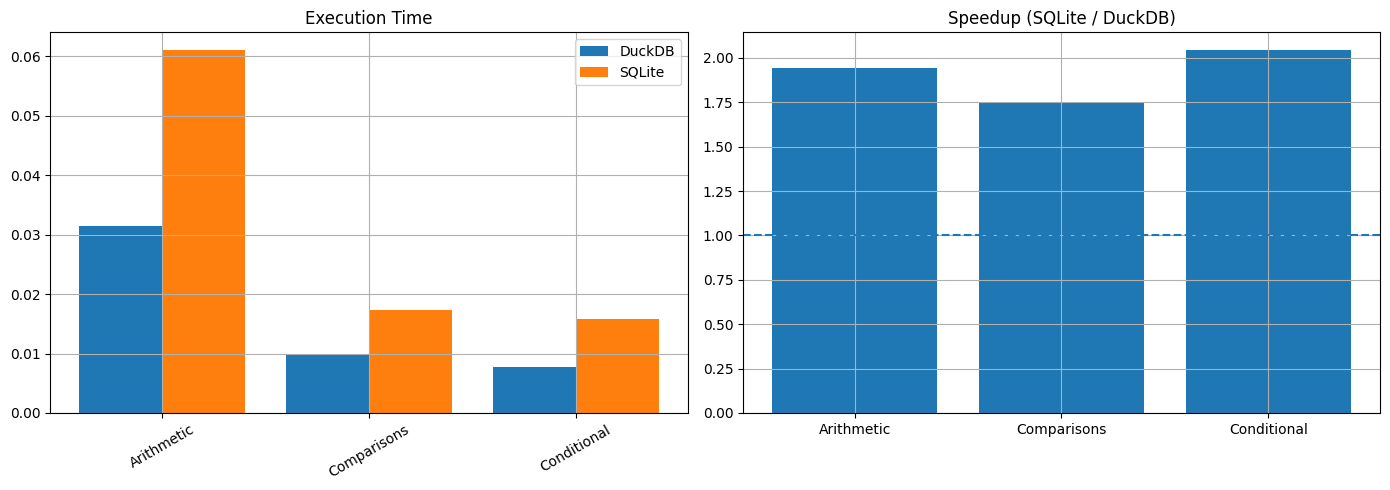

In [ ]:
"""
Experiment 2: SIMD Impact on TPC-H Dataset
DuckDB (vectorized + SIMD) vs SQLite (row-based)
"""

import duckdb
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

def init_tpch(scale_factor=0.1):
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H data (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    
    print("TPC-H ready.\n")
    return con


# -----------------------------
# 2. Prepare SAME dataset
# -----------------------------
def prepare_tpch_subset(con, rows=200_000):
    """
    Extract subset from TPC-H and load into SQLite
    """
    
    df = con.execute(f"""
        SELECT
            l_orderkey,
            l_quantity,
            l_extendedprice,
            l_discount,
            l_tax,
            l_shipdate
        FROM lineitem
        LIMIT {rows}
    """).df()

    # Convert date for SQLite
    df["l_shipdate"] = pd.to_datetime(df["l_shipdate"]).dt.strftime("%Y-%m-%d")

    # Register in DuckDB
    con.register("bench_lineitem", df)

    # Load into SQLite
    sqlite_con = sqlite3.connect(":memory:")
    df.to_sql("bench_lineitem", sqlite_con, index=False)

    return sqlite_con


# -----------------------------
# 3. Timing
# -----------------------------
def time_duckdb(con, query):
    start = time.perf_counter()
    result = con.execute(query).fetchall()
    return time.perf_counter() - start, result


def time_sqlite(sqlite_con, query):
    start = time.perf_counter()
    result = sqlite_con.execute(query).fetchall()
    return time.perf_counter() - start, result


# -----------------------------
# 4. Experiment 2 (TPC-H)
# -----------------------------
def experiment_2_tpch(con, sqlite_con):

    print("="*80)
    print("EXPERIMENT 2: SIMD Impact (TPC-H)")
    print("="*80)

    results = {
        "operation": [],
        "duckdb_time": [],
        "sqlite_time": [],
        "speedup": []
    }

    # -------------------------
    # 2.1 Arithmetic
    # -------------------------
    print("\n[2.1] Arithmetic (price * discount)")

    query = """
        SELECT l_orderkey,
               l_extendedprice * (1 - l_discount) AS revenue
        FROM bench_lineitem
        WHERE l_quantity * 2 > 50
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("Arithmetic")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # -------------------------
    # 2.2 Comparisons
    # -------------------------
    print("\n[2.2] Comparisons")

    query = """
        SELECT COUNT(*)
        FROM bench_lineitem
        WHERE l_quantity > 20
          AND l_extendedprice < 50000
          AND l_discount BETWEEN 0.02 AND 0.07
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("Comparisons")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # -------------------------
    # 2.3 NULL-like scenario
    # -------------------------
    print("\n[2.3] Conditional / NULL-like logic")

    query = """
        SELECT COUNT(*)
        FROM bench_lineitem
        WHERE CASE 
                WHEN l_discount IS NULL THEN 0
                ELSE l_discount
              END > 0.03
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("Conditional")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    return results


# -----------------------------
# 5. Plot (Notebook)
# -----------------------------
def plot_experiment_2(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(df))

    # Time comparison
    axes[0].bar(x - 0.2, df["duckdb_time"], 0.4, label="DuckDB")
    axes[0].bar(x + 0.2, df["sqlite_time"], 0.4, label="SQLite")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["operation"], rotation=30)
    axes[0].set_title("Execution Time")
    axes[0].legend()
    axes[0].grid()

    # Speedup
    axes[1].bar(df["operation"], df["speedup"])
    axes[1].set_title("Speedup (SQLite / DuckDB)")
    axes[1].axhline(y=1, linestyle="--")
    axes[1].grid()

    plt.tight_layout()
    plt.show()


# -----------------------------
# 6. RUN (Notebook)
# -----------------------------
con = init_tpch(scale_factor=0.1)

sqlite_con = prepare_tpch_subset(con)

results = experiment_2_tpch(con, sqlite_con)

plot_experiment_2(results)